In [1]:
import torch

def check_gpu_status():
    """
    Checks for CUDA availability and displays details for all available GPUs.
    """
    if torch.cuda.is_available():
        print("✅ CUDA is available! PyTorch can use the GPU.")
        
        # Get the number of available GPUs
        num_gpus = torch.cuda.device_count()
        print(f"Number of available GPUs: {num_gpus}\n")
        
        for i in range(num_gpus):
            # Get properties for each GPU
            gpu_properties = torch.cuda.get_device_properties(i)
            
            # Display information
            print(f"--- GPU Device Index: {i} ---")
            print(f"GPU Name: {gpu_properties.name}")
            
            # Convert total memory from bytes to GB
            total_memory_gb = gpu_properties.total_memory / (1024**3)
            print(f"Total VRAM: {total_memory_gb:.2f} GB")
            print(f"CUDA Capability: {gpu_properties.major}.{gpu_properties.minor}")
            
            # Get current memory usage (allocated and cached)
            allocated_mb = torch.cuda.memory_allocated(i) / (1024**2)
            cached_mb = torch.cuda.memory_reserved(i) / (1024**2)
            print(f"Allocated Memory: {allocated_mb:.2f} MB")
            print(f"Reserved/Cached Memory: {cached_mb:.2f} MB")
            
    else:
        print("❌ CUDA is NOT available. PyTorch is running on the CPU.")

# Run the function to display your GPU status
check_gpu_status()

✅ CUDA is available! PyTorch can use the GPU.
Number of available GPUs: 1

--- GPU Device Index: 0 ---
GPU Name: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Total VRAM: 4.00 GB
CUDA Capability: 8.6
Allocated Memory: 0.00 MB
Reserved/Cached Memory: 0.00 MB


In [1]:
from datasets import load_dataset, load_from_disk
import os

In [2]:


# Get absolute path to data directory (relative to this notebook's location)
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir) if notebook_dir.endswith("src") else os.path.dirname(os.getcwd())
# Handle case where we're running from src directory
if os.getcwd().endswith("src"):
    project_root = os.path.dirname(os.getcwd())
else:
    project_root = os.getcwd()
print ("project root: "+project_root)
data_dir = os.path.join(project_root, "ROCOv2-radiology", "data")
cache_dir = os.path.join(project_root, "src")  # Cache in src folder

print(f"Data directory: {data_dir}")
print(f"Files exist: {os.path.exists(data_dir)}")

# Check if cached version exists for faster loading
train_cache = os.path.join(cache_dir, "roco_train_full")
val_cache = os.path.join(cache_dir, "roco_validation_full")
test_cache = os.path.join(cache_dir, "roco_test_full")

if os.path.exists(train_cache):
    print("Loading from cached Arrow format (fast)...")
    train_dataset = load_from_disk(train_cache)
    val_dataset = load_from_disk(val_cache)
    test_dataset = load_from_disk(test_cache)
else:
    print("Loading from parquet files (first time)...")
    # Use absolute paths with glob pattern
    train_files = os.path.join(data_dir, "train-*.parquet")
    val_files = os.path.join(data_dir, "validation-*.parquet")
    test_files = os.path.join(data_dir, "test-*.parquet")
    
    train_dataset = load_dataset("parquet", data_files=train_files, split="train")
    val_dataset = load_dataset("parquet", data_files=val_files, split="train")
    test_dataset = load_dataset("parquet", data_files=test_files, split="train")
    
    # Cache for faster subsequent loads
    train_dataset.save_to_disk(train_cache)
    val_dataset.save_to_disk(val_cache)
    test_dataset.save_to_disk(test_cache)
    print("✓ Cached to disk")

print(f"\nDataset loaded:")
print(f"Train: {len(train_dataset):,} samples")
print(f"Validation: {len(val_dataset):,} samples")
print(f"Test: {len(test_dataset):,} samples")

project root: /workspace/work
Data directory: /workspace/work/ROCOv2-radiology/data
Files exist: True
Loading from cached Arrow format (fast)...


Loading dataset from disk:   0%|          | 0/27 [00:00<?, ?it/s]


Dataset loaded:
Train: 59,962 samples
Validation: 9,904 samples
Test: 9,927 samples


In [2]:
# ===== From now on, use this (super fast) =====
train_dataset = load_from_disk("roco_train_full")
val_dataset = load_from_disk("roco_validation_full")
test_dataset = load_from_disk("roco_test_full")

print(f"\nLoaded instantly:")
print(f"Train: {len(train_dataset)} samples")
print(f"Validation: {len(val_dataset)} samples")
print(f"Test: {len(test_dataset)} samples")

Loading dataset from disk:   0%|          | 0/27 [00:00<?, ?it/s]


Loaded instantly:
Train: 59962 samples
Validation: 9904 samples
Test: 9927 samples


In [4]:
train_dataset

Dataset({
    features: ['image', 'image_id', 'caption', 'cui'],
    num_rows: 59962
})

In [8]:
from transformers import BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_enable_fp32_cpu_offload=True  # Enable CPU offloading
)

In [13]:

from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

MODEL_NAME = "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit"  # Local testing
# MODEL_NAME = "unsloth/llava-1.5-7b-hf-bnb-4bit"     # Colab training

model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
    device_map = "auto",
    offload_embedding = True,
    quantization_config=bnb_config,  
)



==((====))==  Unsloth 2025.11.2: Fast Qwen2_Vl patching. Transformers: 4.57.0. vLLM: 0.10.2.
   \\   /|    NVIDIA GeForce RTX 3050 Ti Laptop GPU. Num GPUs = 1. Max memory: 4.0 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33+aa7bc36.d20251112. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Offloading embeddings to RAM to save 0.43 GB.


In [14]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


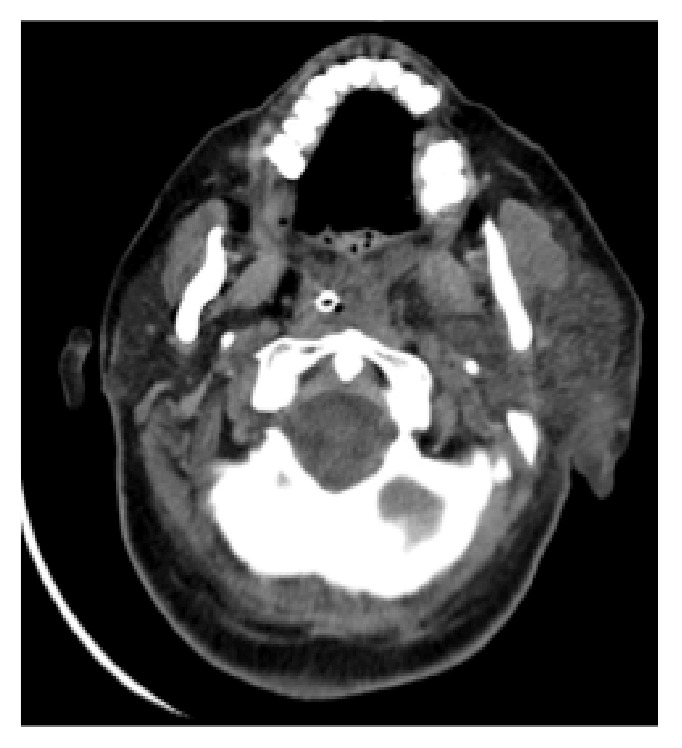

In [21]:
train_dataset[0]["image"]

In [3]:
train_dataset[0]["caption"]

'Head CT demonstrating left parotiditis.'

In [10]:
import multiprocessing

num_cores = multiprocessing.cpu_count()
instruction = "You are an expert radiographer. Describe accurately what you see in this image."
def convert_to_conversation_batched(samples):
    conversations = []
    for i in range(len(samples["image"])):
        conversation = [
            {"role": "user",
             "content": [
                {"type": "text", "text": instruction},
                {"type": "image", "image": samples["image"][i]}
             ]},
            {"role": "assistant",
             "content": [{"type": "text", "text": samples["caption"][i]}]}
        ]
        conversations.append(conversation)
    return {"messages": conversations}


In [11]:

# Convert all datasets
converted_train_dataset = train_dataset.map(
    convert_to_conversation_batched,
    batched=True,
    batch_size=1000,
    num_proc=2,
    remove_columns=train_dataset.column_names,
    writer_batch_size=1000,
    desc="Converting train"
)
converted_train_dataset.save_to_disk("./roco_converted_train")

converted_test_dataset = test_dataset.map(
    convert_to_conversation_batched,
    batched=True,
    batch_size=1000,
    num_proc=2,
    remove_columns=test_dataset.column_names,
    writer_batch_size=1000,
    desc="Converting test"
)

converted_test_dataset.save_to_disk("./roco_converted_test")

converted_validation_dataset = val_dataset.map(
    convert_to_conversation_batched,
    batched=True,
    batch_size=1000,
    num_proc=2,
    remove_columns=val_dataset.column_names,
    writer_batch_size=1000,
    desc="Converting validation"
)

# Save once, never do this again

converted_validation_dataset.save_to_disk("./roco_converted_validation")

print("✓ Datasets converted and saved!")

Converting train (num_proc=2):   0%|          | 0/59962 [00:00<?, ? examples/s]

Converting test (num_proc=2):   0%|          | 0/9927 [00:00<?, ? examples/s]

Converting validation (num_proc=2):   0%|          | 0/9904 [00:00<?, ? examples/s]

Saving the dataset (0/27 shards):   0%|          | 0/59962 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/9927 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/9904 [00:00<?, ? examples/s]

✓ Datasets converted and saved!


In [13]:
converted_train_dataset[0]

{'messages': [{'content': [{'image': None,
     'text': 'You are an expert radiographer. Describe accurately what you see in this image.',
     'type': 'text'},
    {'image': {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\xaa\x00\x00\x02\xec\x08\x02\x00\x00\x00\xa4\xe6\x02L\x00\x01\x00\x00IDATx\x9c\xec\xfdY\xaf]\xcb\x95%\x06\xcf\x88\xb5\xfb\xd3\x92\x87}+R\xba\x9dz(\xdd(+\x85\xcc\x07\xbb\n.\xc0\x80\xabP0\xe0G\xc3\xaf\xfe\x15\xfe\x0b\xf5P?\xc0\x8f\xf6\x93!\xa0\n\x85\x82\xedt\xa5\x94\xa9\xaa\xac\xcc,\xa5\xa4\xd4\xd5\xd5\xbd\xd2\xedH^\xf6\xa7\xdf\xed\x8a\xf8\x1e\x06\xe6\xf8\xc6Z\xfb\x90"yI^\x92\'\xe6\xc3\xc1>{\xaf&V\xac\x88\xd9\x8c\xd9\x85\x9c\xb3\x15*T\xa8P\xa1B\x85\x8e\x13\xc5\xafz\x00\x85\n\x15*T\xa8P\xa1\x97ME\xfc\x17*T\xa8P\xa1B\xc7\x8e\x8a\xf8/T\xa8P\xa1B\x85\x8e\x1d\x15\xf1_\xa8P\xa1B\x85\n\x1d;*\xe2\xbfP\xa1B\x85\n\x15:vT\xc4\x7f\xa1B\x85\n\x15*t\xec\xa8\x88\xffB\x85\n\x15*T\xe8\xd8Q\x11\xff\x85\n\x15*T\xa8\xd0\xb1\xa3"\xfe\x0b\x15*T\xa8P\xa1cGE\xfc\x17*T\xa8P\xa1B\xc7

Loading dataset from disk:   0%|          | 0/27 [00:00<?, ?it/s]

Sample structure: {'messages': [{'content': [{'image': None, 'text': 'You are an expert radiographer. Describe accurately what you see in this image.', 'type': 'text'}, {'image': {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\xaa\x00\x00\x02\xec\x08\x02\x00\x00\x00\xa4\xe6\x02L\x00\x01\x00\x00IDATx\x9c\xec\xfdY\xaf]\xcb\x95%\x06\xcf\x88\xb5\xfb\xd3\x92\x87}+R\xba\x9dz(\xdd(+\x85\xcc\x07\xbb\n.\xc0\x80\xabP0\xe0G\xc3\xaf\xfe\x15\xfe\x0b\xf5P?\xc0\x8f\xf6\x93!\xa0\n\x85\x82\xedt\xa5\x94\xa9\xaa\xac\xcc,\xa5\xa4\xd4\xd5\xd5\xbd\xd2\xedH^\xf6\xa7\xdf\xed\x8a\xf8\x1e\x06\xe6\xf8\xc6Z\xfb\x90"yI^\x92\'\xe6\xc3\xc1>{\xaf&V\xac\x88\xd9\x8c\xd9\x85\x9c\xb3\x15*T\xa8P\xa1B\x85\x8e\x13\xc5\xafz\x00\x85\n\x15*T\xa8P\xa1\x97ME\xfc\x17*T\xa8P\xa1B\xc7\x8e\x8a\xf8/T\xa8P\xa1B\x85\x8e\x1d\x15\xf1_\xa8P\xa1B\x85\n\x1d;*\xe2\xbfP\xa1B\x85\n\x15:vT\xc4\x7f\xa1B\x85\n\x15*t\xec\xa8\x88\xffB\x85\n\x15*T\xe8\xd8Q\x11\xff\x85\n\x15*T\xa8\xd0\xb1\xa3"\xfe\x0b\x15*T\xa8P\xa1cGE\xfc\x17*T\xa8P\xa1B

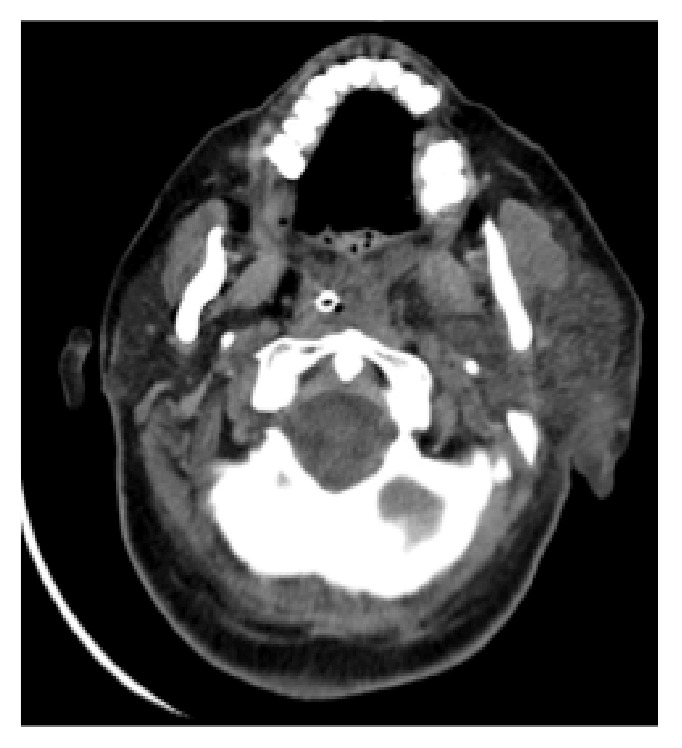


Caption: Head CT demonstrating left parotiditis.

✓ Image saved as 'test_image.jpg'


In [14]:
from datasets import load_from_disk
from PIL import Image
import io

# Load your converted dataset
converted_train_dataset = load_from_disk("./roco_converted_train")

# Get a sample
sample = converted_train_dataset[0]  # First sample
print("Sample structure:", sample)
print("\n" + "="*50 + "\n")

# Extract the image from the conversation format
# The image is in messages[0]['content'][1]['image']
conversation = sample['messages']
user_message = conversation[0]  # First message (user role)
image_content = user_message['content'][1]  # Second content item (the image)
image_bytes = image_content['image']

print(f"Image type: {type(image_bytes)}")
print(f"Image bytes length: {len(image_bytes['bytes']) if isinstance(image_bytes, dict) else 'N/A'}")
print("\n" + "="*50 + "\n")

# Convert bytes to PIL Image
if isinstance(image_bytes, dict) and 'bytes' in image_bytes:
    # If stored as dict with 'bytes' key
    img = Image.open(io.BytesIO(image_bytes['bytes']))
elif isinstance(image_bytes, bytes):
    # If stored directly as bytes
    img = Image.open(io.BytesIO(image_bytes))
else:
    # If it's already a PIL Image
    img = image_bytes

# Display image info
print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")
print(f"Image format: {img.format}")

# Show the image
img.show()

# Also print the corresponding caption
assistant_message = conversation[1]  # Second message (assistant role)
caption = assistant_message['content'][0]['text']
print(f"\nCaption: {caption}")

# Save to file if you want
img.save("test_image.jpg")
print("\n✓ Image saved as 'test_image.jpg'")

In [ ]:
converted_train_dataset[0]